# 🛒 E-Commerce Recommendation System (Beginner Project)

**Goal:** Build a simple recommendation system that suggests products to customers,
using their past shopping behaviour. We will also group customers into segments
using K-Means clustering.

**Dataset:** `ecommerce_user_behavior_8000.csv`

This notebook is written in simple English with comments on every step,
so it is easy to follow even if you are new to Machine Learning.

## Step 1: Import Libraries
We import all the tools (libraries) we need for data handling, plotting, and machine learning.

In [ ]:
# Pandas and NumPy help us work with data (tables and numbers)
import pandas as pd
import numpy as np

# Matplotlib and Seaborn help us make graphs
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn gives us ready-made Machine Learning tools
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.cluster import KMeans

# Make plots look nicer
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (7, 4)

print("All libraries imported successfully!")

All libraries imported successfully!


## Step 2: Load the Dataset
We read the CSV file into a Pandas DataFrame (a table-like structure).

In [ ]:
# Load the dataset from the CSV file
df = pd.read_csv("ecommerce_user_behavior_8000.csv")

# Look at the first 5 rows to understand the data
print("Shape of dataset (rows, columns):", df.shape)
df.head()

Shape of dataset (rows, columns): (8040, 14)


,user_id,age,gender,annual_income,membership_years,product_id,product_name,category,price,avg_product_rating,purchase_count,time_spent_minutes,user_rating_given,last_purchase_days_ago
0,U0316,63,Male,31120.0,4.0,P0154,Grocery Item 154,Grocery,341.52,3.8,2,22.2,2.0,132
1,U0767,32,Female,43478.0,4.5,P0281,Books Item 281,Books,36.44,4.7,4,8.0,4.0,324
2,U0136,23,Female,100650.0,7.7,P0278,Home Item 278,Home & Kitchen,199.53,4.0,2,52.9,5.0,79
3,U0788,42,Male,125426.0,0.4,P0167,Health Item 167,Health,478.62,2.8,1,38.4,3.0,314
4,U0514,27,Female,39503.0,2.2,P0119,Toys Item 119,Toys,406.55,4.8,4,42.4,3.0,351


## Step 3: Data Cleaning
Real-world data is often messy. Here we:
1. Check for missing values
2. Fill or remove missing values
3. Remove duplicate rows

In [ ]:
# Check how many missing values are in each column
print("Missing values before cleaning:")
print(df.isnull().sum()[df.isnull().sum() > 0])

# Fill missing numeric values with the column's median (a simple, safe choice)
df["user_rating_given"] = df["user_rating_given"].fillna(df["user_rating_given"].median())
df["time_spent_minutes"] = df["time_spent_minutes"].fillna(df["time_spent_minutes"].median())
df["annual_income"] = df["annual_income"].fillna(df["annual_income"].median())

# Check and remove duplicate rows
print("\nDuplicate rows found:", df.duplicated().sum())
df = df.drop_duplicates().reset_index(drop=True)

print("\nMissing values after cleaning:", df.isnull().sum().sum())
print("Final shape after cleaning:", df.shape)

Missing values before cleaning:
annual_income         20
time_spent_minutes    50
user_rating_given     80
dtype: int64

Duplicate rows found: 40

Missing values after cleaning: 0
Final shape after cleaning: (8000, 14)


## Step 4: Exploratory Data Analysis (EDA)
Let's visualize the data to understand customer behaviour and product trends.
We will make 5 simple graphs.

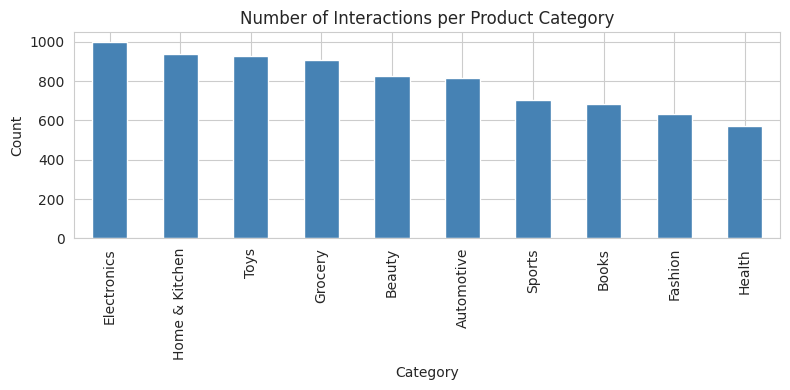

In [ ]:
# Graph 1: Number of products in each category
plt.figure(figsize=(8,4))
df["category"].value_counts().plot(kind="bar", color="steelblue")
plt.title("Number of Interactions per Product Category")
plt.xlabel("Category")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

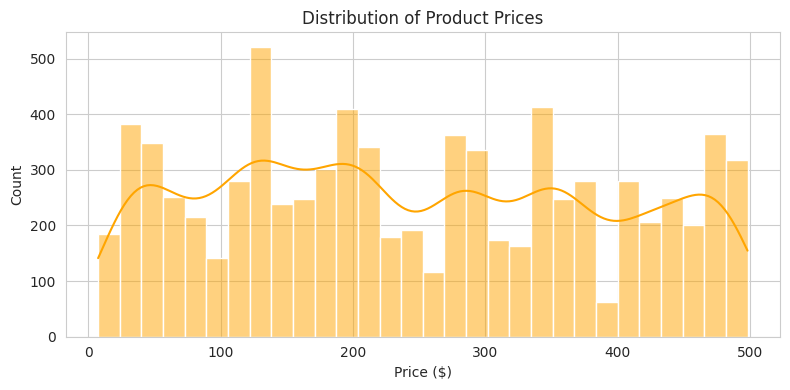

In [ ]:
# Graph 2: Distribution of product prices
plt.figure(figsize=(8,4))
sns.histplot(df["price"], bins=30, kde=True, color="orange")
plt.title("Distribution of Product Prices")
plt.xlabel("Price ($)")
plt.tight_layout()
plt.show()

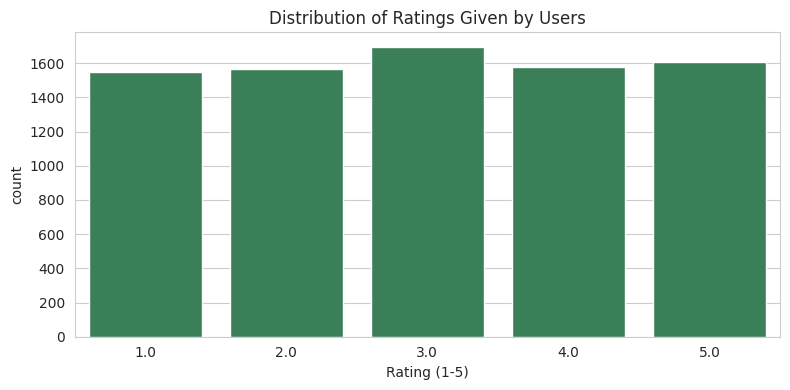

In [ ]:
# Graph 3: Distribution of ratings given by users
plt.figure(figsize=(8,4))
sns.countplot(x="user_rating_given", data=df, color="seagreen")
plt.title("Distribution of Ratings Given by Users")
plt.xlabel("Rating (1-5)")
plt.tight_layout()
plt.show()

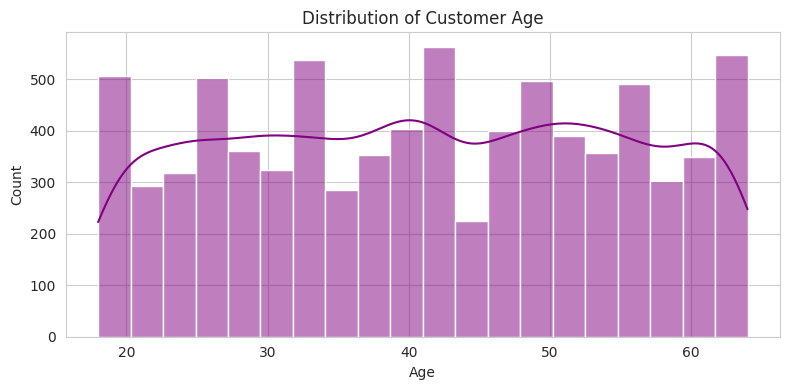

In [ ]:
# Graph 4: Distribution of customer age
plt.figure(figsize=(8,4))
sns.histplot(df["age"], bins=20, color="purple", kde=True)
plt.title("Distribution of Customer Age")
plt.xlabel("Age")
plt.tight_layout()
plt.show()

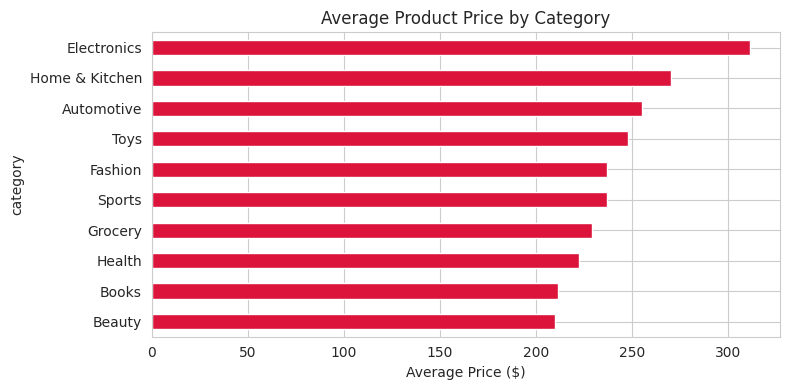

In [ ]:
# Graph 5: Average price per category (helps us see which categories are costly)
plt.figure(figsize=(8,4))
df.groupby("category")["price"].mean().sort_values().plot(kind="barh", color="crimson")
plt.title("Average Product Price by Category")
plt.xlabel("Average Price ($)")
plt.tight_layout()
plt.show()

## Step 5: Build a Content-Based Recommendation System
**Idea:** Products that are similar to each other (same category, similar price,
similar rating) can be recommended to a user who liked one of them.

We use **Cosine Similarity**, which measures how "close" two products are,
based on their features.

In [ ]:
# Build a table with one row per unique product (its features)
products = df[["product_id","product_name","category","price","avg_product_rating"]].drop_duplicates("product_id").reset_index(drop=True)

# Turn category into numeric columns using One-Hot Encoding (0s and 1s)
category_encoded = pd.get_dummies(products["category"])

# Scale price and rating so they are between 0 and 1 (fair comparison)
scaler = MinMaxScaler()
scaled_num = scaler.fit_transform(products[["price","avg_product_rating"]])
scaled_num = pd.DataFrame(scaled_num, columns=["price_scaled","rating_scaled"])

# Combine all features into one final feature table
product_features = pd.concat([category_encoded, scaled_num], axis=1)

print("Product feature table shape:", product_features.shape)
product_features.head()

Product feature table shape: (300, 12)


,Automotive,Beauty,Books,Electronics,Fashion,Grocery,Health,Home & Kitchen,Sports,Toys,price_scaled,rating_scaled
0,False,False,False,False,False,True,False,False,False,False,0.680947,0.52
1,False,False,True,False,False,False,False,False,False,False,0.058868,0.88
2,False,False,False,False,False,False,False,True,False,False,0.391420,0.60
3,False,False,False,False,False,False,True,False,False,False,0.960503,0.12
4,False,False,False,False,False,False,False,False,False,True,0.813548,0.92


In [ ]:
# Calculate cosine similarity between every pair of products
similarity_matrix = cosine_similarity(product_features)

# Convert to a DataFrame so we can look up by product_id
similarity_df = pd.DataFrame(similarity_matrix, index=products["product_id"], columns=products["product_id"])

print("Similarity matrix shape:", similarity_df.shape)
similarity_df.iloc[:5, :5]

Similarity matrix shape: (300, 300)


product_id,P0154,P0281,P0278,P0167,P0119
product_id,,,,,
P0154,1.000000,0.283446,0.357146,0.390922,0.495016
P0281,0.283446,1.000000,0.335959,0.087375,0.406064
P0278,0.357146,0.335959,1.000000,0.261655,0.446789
P0167,0.390922,0.087375,0.261655,1.000000,0.404602
P0119,0.495016,0.406064,0.446789,0.404602,1.000000


In [ ]:
def recommend_similar_products(product_id, top_n=5):
    """Given a product_id, return the top_n most similar products."""
    # Get similarity scores for this product, sorted highest first
    scores = similarity_df[product_id].sort_values(ascending=False)
    # Remove the product itself from the list
    scores = scores.drop(product_id)
    top_ids = scores.head(top_n).index
    return products[products["product_id"].isin(top_ids)][["product_id","product_name","category","price","avg_product_rating"]]

# Test: find products similar to the first product in our catalog
sample_product = products["product_id"].iloc[0]
print("Products similar to:", sample_product)
recommend_similar_products(sample_product)

Products similar to: P0154


,product_id,product_name,category,price,avg_product_rating
26,P0273,Grocery Item 273,Grocery,389.91,4.0
65,P0013,Grocery Item 13,Grocery,422.89,3.7
119,P0286,Grocery Item 286,Grocery,347.40,4.0
137,P0050,Grocery Item 50,Grocery,270.86,3.5
214,P0100,Grocery Item 100,Grocery,326.64,3.8


In [ ]:
def recommend_for_user(user_id, top_n=5):
    """
    Recommend products for a user based on products they already interacted with.
    Steps:
    1. Find products the user has already bought.
    2. Find products similar to each of those.
    3. Remove products the user already has.
    4. Return the top_n highest-scoring new products.
    """
    user_products = df[df["user_id"] == user_id]["product_id"].unique()

    if len(user_products) == 0:
        return "No purchase history found for this user."

    # Average similarity score across all products the user has bought
    scores = similarity_df[user_products].mean(axis=1).sort_values(ascending=False)

    # Remove products the user has already purchased
    scores = scores.drop(labels=user_products, errors="ignore")

    top_ids = scores.head(top_n).index
    result = products[products["product_id"].isin(top_ids)][["product_id","product_name","category","price","avg_product_rating"]]
    return result.assign(similarity_score=scores[top_ids].values).sort_values("similarity_score", ascending=False)

## Step 6: Customer Segmentation using K-Means Clustering
**Idea:** Group customers into clusters (segments) based on their behaviour,
like spending, ratings given, and browsing time. This helps a business
understand different types of customers (e.g. "high spenders", "casual browsers").

In [ ]:
# Create one row per customer, summarizing their overall behaviour
customer_features = df.groupby("user_id").agg(
    total_spent=("price", "sum"),
    avg_rating_given=("user_rating_given", "mean"),
    total_purchases=("purchase_count", "sum"),
    avg_time_spent=("time_spent_minutes", "mean"),
    age=("age", "first"),
    annual_income=("annual_income", "first")
).reset_index()

print("Customer feature table shape:", customer_features.shape)
customer_features.head()

Customer feature table shape: (1200, 7)


,user_id,total_spent,avg_rating_given,total_purchases,avg_time_spent,age,annual_income
0,U0001,1257.87,3.333333,20,38.716667,37,115998.0
1,U0002,737.57,4.333333,8,35.633333,39,69812.0
2,U0003,1036.11,2.428571,18,29.385714,45,70500.0
3,U0004,394.69,3.250000,9,32.800000,57,99151.0
4,U0005,729.03,4.000000,7,13.350000,24,78643.0


In [ ]:
# Scale the features so K-Means treats them fairly (equal importance)
features_to_scale = ["total_spent","avg_rating_given","total_purchases","avg_time_spent","age","annual_income"]
scaler2 = StandardScaler()
X_scaled = scaler2.fit_transform(customer_features[features_to_scale])

# Train a K-Means model with 4 customer segments
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
customer_features["segment"] = kmeans.fit_predict(X_scaled)

print("Number of customers in each segment:")
print(customer_features["segment"].value_counts().sort_index())

Number of customers in each segment:
segment
0    261
1    321
2    298
3    320
Name: count, dtype: int64


In [ ]:
# Look at the average behaviour of each segment - this helps us name/understand them
segment_summary = customer_features.groupby("segment")[features_to_scale].mean().round(1)
print("Average behaviour per customer segment:")
segment_summary

Average behaviour per customer segment:


,total_spent,avg_rating_given,total_purchases,avg_time_spent,age,annual_income
segment,,,,,,
0,1152.4,3.7,14.8,27.4,43.1,87011.0
1,2512.9,3.1,30.2,31.0,42.7,85508.6
2,1440.7,2.7,17.6,28.4,41.7,47934.7
3,1358.1,2.7,16.5,34.2,37.9,113101.5


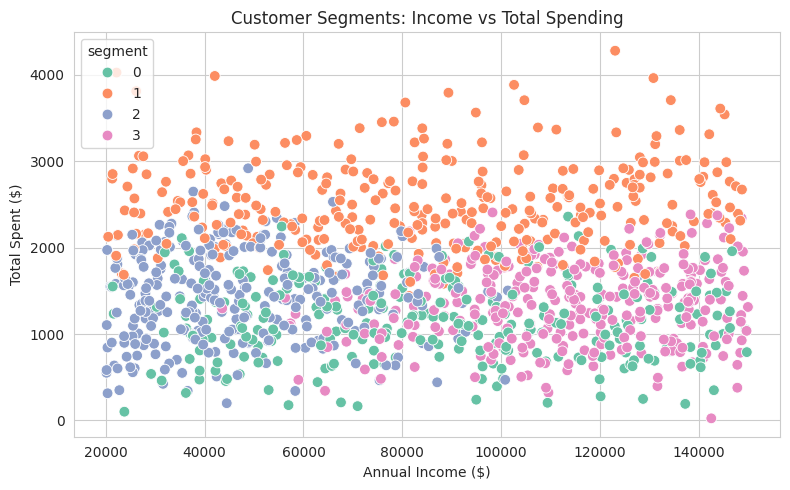

In [ ]:
# Bonus Graph: Visualize customer segments (Total Spent vs Annual Income)
plt.figure(figsize=(8,5))
sns.scatterplot(data=customer_features, x="annual_income", y="total_spent",
                 hue="segment", palette="Set2", s=60)
plt.title("Customer Segments: Income vs Total Spending")
plt.xlabel("Annual Income ($)")
plt.ylabel("Total Spent ($)")
plt.tight_layout()
plt.show()

## Step 7: What Do These Results Mean?

- **Cosine Similarity Recommendation:** Products with similar category, price
  range, and rating get a high similarity score (close to 1). We used this to
  recommend new products to a customer based on what they already bought.
- **K-Means Segments:** Customers are grouped into 4 segments based on spending,
  ratings, browsing time, age, and income. A business can use this to design
  different marketing offers for each segment (e.g. discounts for low spenders,
  loyalty rewards for high spenders).

## Step 8: Show Top 5 Recommended Products for a Sample Customer

In [ ]:
# Pick a sample user from the dataset
sample_user = df["user_id"].iloc[0]

print(f"Top 5 Recommended Products for user: {sample_user}\n")
recommendations = recommend_for_user(sample_user, top_n=5)
recommendations

Top 5 Recommended Products for user: U0316



,product_id,product_name,category,price,avg_product_rating,similarity_score
17,P0269,Electronics Item 269,Electronics,438.95,4.6,0.684546
36,P0176,Electronics Item 176,Electronics,473.37,5.0,0.684282
182,P0079,Electronics Item 79,Electronics,467.63,4.8,0.683214
270,P0022,Electronics Item 22,Electronics,425.09,4.1,0.682322
280,P0111,Electronics Item 111,Electronics,472.23,3.9,0.682150


## Conclusion
In this project we:
1. Cleaned a messy e-commerce dataset
2. Explored the data with graphs
3. Built a content-based recommendation system using cosine similarity
4. Segmented customers using K-Means clustering
5. Displayed personalized product recommendations for a sample customer

This is a simple, beginner-friendly example. In real companies, recommendation
systems use much larger datasets and more advanced techniques
(like collaborative filtering and deep learning), but the core idea stays the same!